# Feature Engineering


#### Objective
##### To create meaningful feature from raw data. It's main aim to capture consumer behaviou more effectively than basic statistical features

In [107]:
%matplotlib inline
import pandas as pd
import numpy as np 
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
data_path=Path(r'C:\Users\vinee\ML_Project\data\raw\electricity_consumption_raw.csv')
df1=pd.read_csv(data_path)
%store -r consumer_feature

#### Feature 1: Coefficient of Variation (CV)
##### SD measures the absolute variability while CV normalize the SD by the average consumption  making variability comparable accross all consumers.

In [108]:
# formula : CV = SD/AVG
consumer_feature['cv']=(consumer_feature['std_cons']/(consumer_feature['mean_cons']+1)) # if the mean is 0 than prevent from error
consumer_feature['cv'].describe()
consumer_feature[['mean_cons','std_cons','cv']].head(10)

,mean_cons,std_cons,cv
0,0.947796,3.101514,1.592320
1,4.606312,7.107997,1.267856
2,8.312549,10.289867,1.104946
3,3.638446,7.999479,1.724603
4,67.649718,64.411585,0.938264
5,8.492054,8.391048,0.884008
6,10.501853,4.148402,0.360672
7,6.703457,3.174117,0.412038
8,16.944037,10.881558,0.606416
9,53.009620,24.224309,0.448518


In [109]:
normal=consumer_feature.loc[consumer_feature.FLAG==0,'cv']
flagged=consumer_feature.loc[consumer_feature.FLAG==1,'cv']

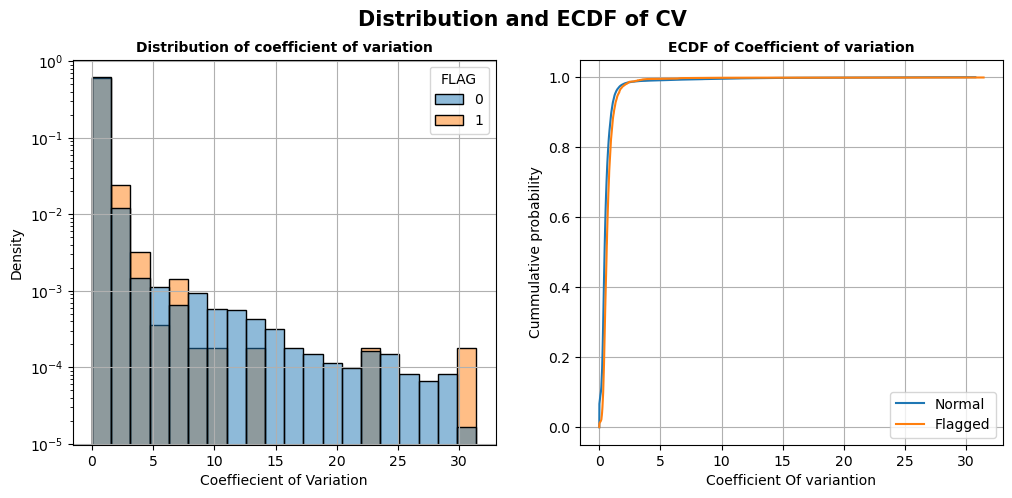

<Figure size 640x480 with 0 Axes>

In [110]:
# visualization 1 Distribution and visulization 2 ECDF
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.distributions.empirical_distribution import ECDF

fig,ax=plt.subplots(1,2,figsize=(12,5))
sns.histplot(data=consumer_feature,x='cv',hue='FLAG',
bins=20,stat='density',common_norm=False,alpha=0.5,ax=ax[0])
ax[0].set_xlabel("Coeffiecient of Variation")
ax[0].set_title("Distribution of coefficient of variation",fontweight='bold',fontsize=10)
ax[0].set_ylabel("Density")
ax[0].set_yscale('log')
ax[0].grid()
# ECDF Graph
ecdf_normal=ECDF(normal)
ecdf_flagged=ECDF(flagged)
ax[1].plot(ecdf_normal.x,ecdf_normal.y,label='Normal')
ax[1].plot(ecdf_flagged.x,ecdf_flagged.y,label='Flagged')
plt.legend()
ax[1].set_xlabel('Coefficient Of variantion')
ax[1].set_ylabel('Cummulative probability')
ax[1].set_title('ECDF of Coefficient of variation',fontsize=10,fontweight='bold')
plt.grid(alpha=1)

fig.suptitle("Distribution and ECDF of CV",fontsize=15,fontweight='bold')
plt.show()
plt.tight_layout()

##### Observation and Key finidings 
##### 1. Highly right skewed 
##### 2. Histogram shows substantial overlap between Normal and Flagged consumers across almost the entire CV range 
##### 3. Flagged consumer have slightly higher ralative variability 
##### 4. ECDF indicate nearly identical distribution "Weak Class Sepration"
##### 5. CV capture useful behaviour information but provide 'limited discrimination' by itself.

#### Feature 2: Mean-Median gap (MMG)
##### mean median gap quantifies the impact of extreme observations and consumer with larger MMG may have experience sudden abnormal spikes in electricity usage

In [111]:
# formula : Mean-Median gap = mean - median
# larger value -> large spikes
consumer_feature['MMG']=(consumer_feature['mean_cons']-consumer_feature['median_cons'])
consumer_feature['MMG'].describe()

count    42367.000000
mean         1.273914
std         12.862376
min      -1278.900000
25%          0.082601
50%          0.531028
75%          1.386051
max        977.006960
Name: MMG, dtype: float64

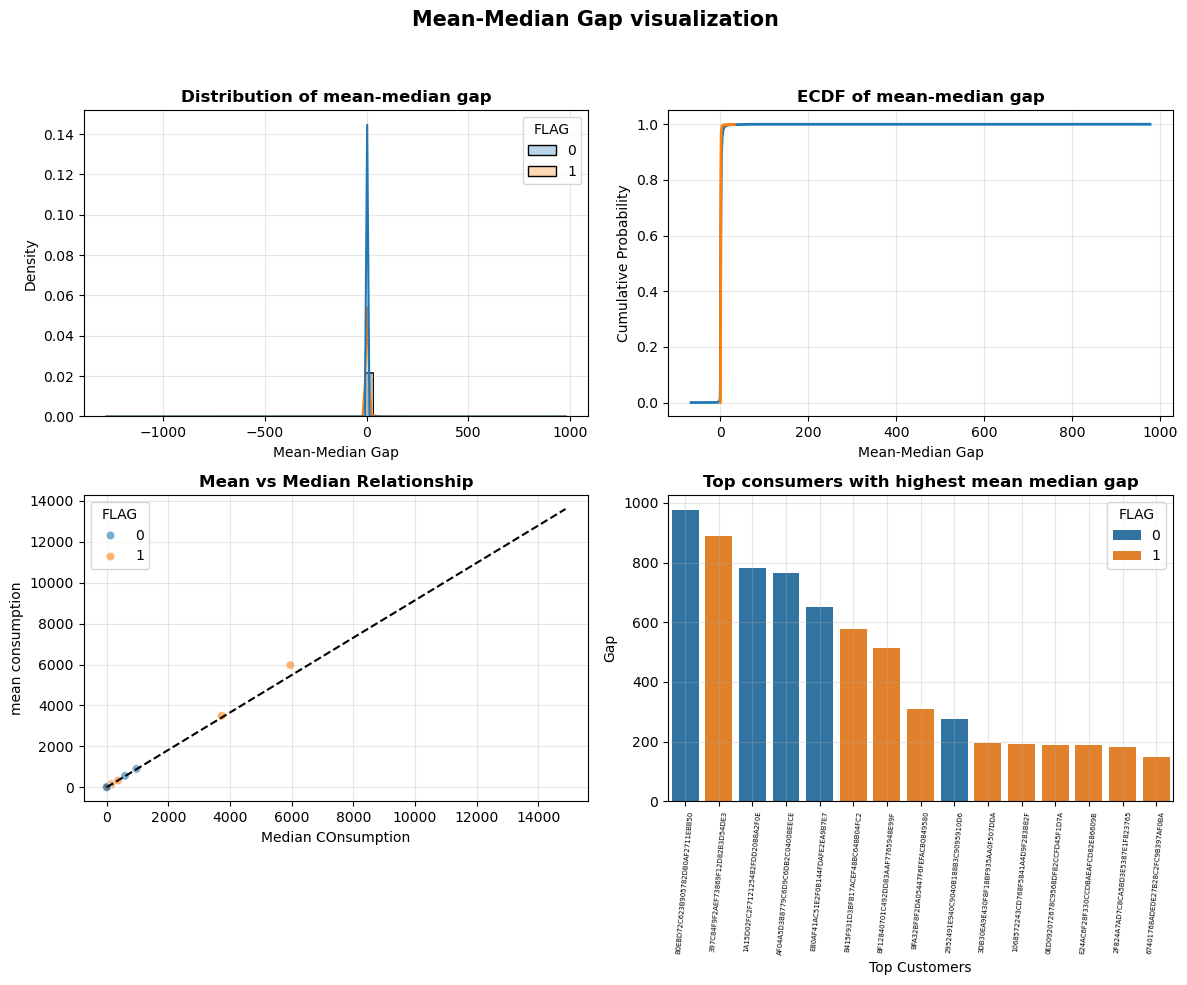

In [112]:
fig,ax=plt.subplots(2,2,figsize=(12,10))
# visualiczation 1 : distribution plot
sns.histplot(
    data=consumer_feature,x='MMG',hue='FLAG',kde=True,
    bins=50,stat='density',common_norm=False,alpha=0.3,ax=ax[0,0]
)
ax[0,0].set_xlabel('Mean-Median Gap')
ax[0,0].set_ylabel('Density')
ax[0,0].set_title('Distribution of mean-median gap',fontsize=12,fontweight='bold')
ax[0,0].grid(alpha=0.3)

# Visualization 2 : ECDF of mean-median gap
normal=consumer_feature.loc[consumer_feature.FLAG==0,'MMG']
Flagged=consumer_feature.loc[consumer_feature.FLAG==1,'MMG']
ecdf_normal=ECDF(normal)
ecdf_flagged=ECDF(flagged)
ax[0,1].plot(ecdf_normal.x,ecdf_normal.y,label='normal',linewidth=2)
ax[0,1].plot(ecdf_flagged.x,ecdf_flagged.y,label='Flagged',linewidth=2)
ax[0,1].set_xlabel('Mean-Median Gap')
ax[0,1].set_ylabel('Cumulative Probability')
ax[0,1].set_title('ECDF of mean-median gap',fontsize=12,fontweight='bold')
ax[0,1].grid(alpha=0.3)

# Visualization 3 : Scatter plot
sns.scatterplot(
    data=consumer_feature.sample(1500,random_state=42),
    x='median_cons',y='mean_cons',hue='FLAG',
    alpha=0.6,ax=ax[1,0]
)
ax[1,0].plot(
    [0,consumer_feature['median_cons'].max()],
    [0,consumer_feature['mean_cons'].max()],
    color='black',linestyle='--',label='mean = median'
)
ax[1,0].set_xlabel('Median COnsumption')
ax[1,0].set_ylabel('mean consumption')
ax[1,0].set_title('Mean vs Median Relationship',fontsize=12,fontweight='bold')
ax[1,0].grid(alpha=0.3)

# visualization 4 : top consumers
top_gap=(consumer_feature.nlargest(15,'MMG'))
sns.barplot(data=top_gap,x='CONS_NO',y='MMG',hue='FLAG',ax=ax[1,1])
ax[1,1].set_xlabel('Top Customers')
ax[1,1].set_ylabel('Gap')
ax[1,1].set_title('Top consumers with highest mean median gap',fontsize=12,fontweight='bold')
ax[1,1].grid(alpha=0.3)
ax[1,1].tick_params(axis="x", rotation=85, labelsize=5)
fig.suptitle("Mean-Median Gap visualization",fontsize=15,fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

##### Observation and key findings 
##### 1. The mean-median gap is highly concentraed near zero indicating that most consumer have fairly consistent cosumptionn patterns.
##### 2. Both connsumers exhibit substantial overlap -> cannot clearly distinguish suspicious consumer
##### 3. only few consumer have a large MMG -> occassional extreme consumption spikes.
##### 4. Useful : indetifies spike driven behaviour associated with abnormal behaviour
##### 5. Limitation : strong overlap between normal and flagged consumer.

#### Feature 3: Zero Consumption Ratio (ZCR)
##### The zero consumption ratio normalize zero-consumption days by the number of available readings, providing a more relaiable measure. it may indicate meter bypassing, illegal connection or irregular electricity usage

In [113]:
# ZCR = (Zero-consumption day)/(valid reading days)
# valid reading days = Total days - missing days
Total_days = len(list(df1.drop(['CONS_NO',"FLAG"],axis=1).columns))
consumer_feature['valid_days']=(Total_days-consumer_feature['missing_days'])
consumer_feature['zero_ratio']=(consumer_feature['zero_days']/consumer_feature['valid_days'])

In [114]:
# Validation 
consumer_feature[['zero_days','missing_days','valid_days','zero_ratio']].head(5)

,zero_days,missing_days,valid_days,zero_ratio
0,862,4,1030,0.836893
1,50,188,846,0.059102
2,34,320,714,0.047619
3,797,17,1017,0.783677
4,38,679,355,0.107042


In [115]:
consumer_feature['zero_ratio'].describe()

count    42367.000000
mean         0.179531
std          0.319880
min          0.000000
25%          0.000000
50%          0.006944
75%          0.169005
max          1.000000
Name: zero_ratio, dtype: float64

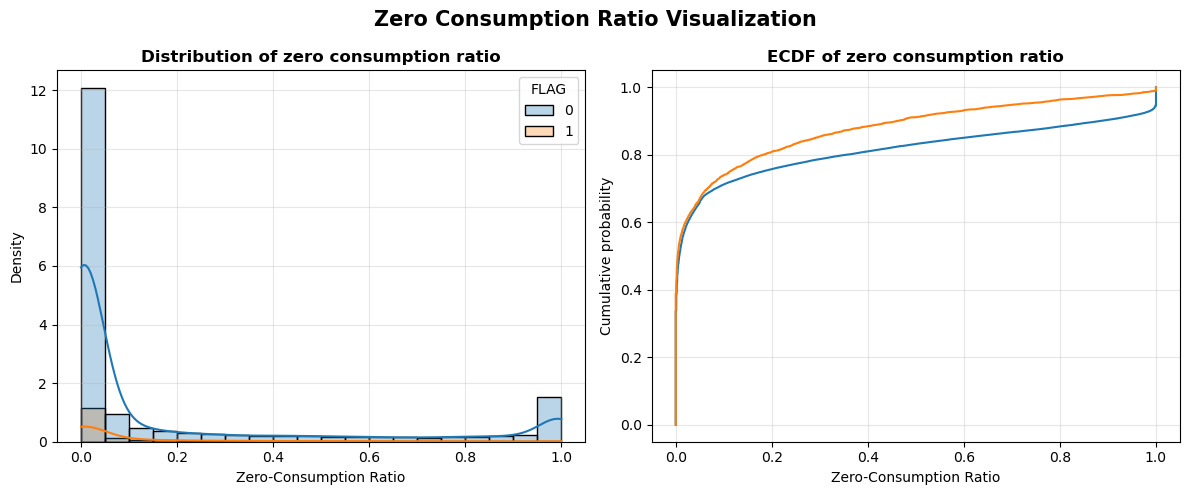

In [116]:
# Visualtization 1 : Histogrram with KDE plot
fig,ax=plt.subplots(1,2,figsize=(12,5))
sns.histplot(
    data=consumer_feature,x='zero_ratio',hue="FLAG",kde=True,
    bins=20,ax=ax[0],stat='density',alpha=0.3
)
ax[0].set_xlabel("Zero-Consumption Ratio")
ax[0].set_ylabel("Density")
ax[0].set_title("Distribution of zero consumption ratio",fontsize=12,fontweight='bold')
ax[0].grid(alpha=0.3)

# Visualtization 2 : ECDF plot 
normal=consumer_feature.loc[consumer_feature.FLAG==0,'zero_ratio']
flagged=consumer_feature.loc[consumer_feature.FLAG==1,'zero_ratio']
ecdf_flagged=ECDF(flagged)
ecdf_normal=ECDF(normal)
ax[1].plot(ecdf_normal.x,ecdf_normal.y,label="Normal")
ax[1].plot(ecdf_flagged.x,ecdf_flagged.y,label="Flagged")
ax[1].set_xlabel("Zero-Consumption Ratio")
ax[1].set_ylabel("Cumulative probability")
ax[1].set_title("ECDF of zero consumption ratio",fontsize=12,fontweight='bold')
ax[1].grid(alpha=0.3)
fig.suptitle("Zero Consumption Ratio Visualization",fontsize=15,fontweight='bold')

plt.tight_layout()
plt.show()

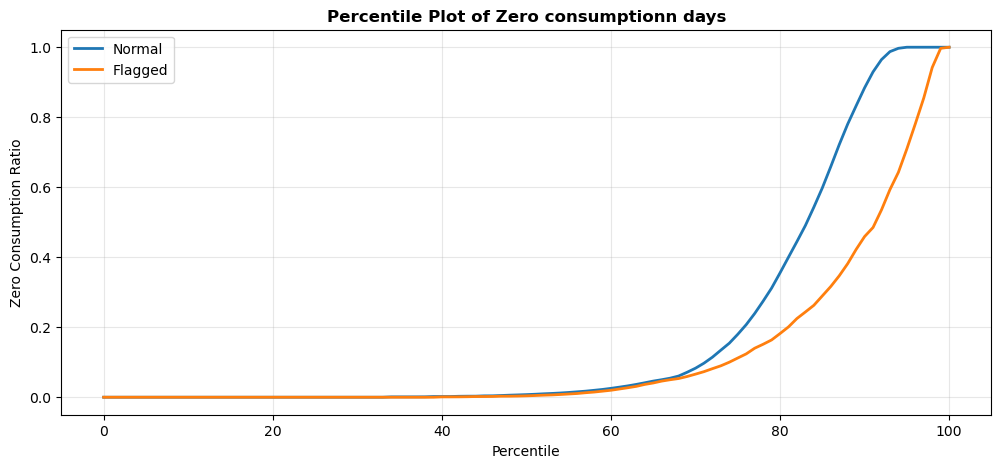

In [117]:
# Percentile Plot 
plt.figure(figsize=(12,5))
percentiles = np.arange(0,101)
norm=normal.dropna()
flag=flagged.dropna()
normal_pct= np.percentile(norm,percentiles)
flagged_pct= np.percentile(flag,percentiles)
plt.plot(percentiles,normal_pct,label='Normal',linewidth=2)
plt.plot(percentiles,flagged_pct,label='Flagged',linewidth=2)
plt.xlabel('Percentile')
plt.ylabel('Zero Consumption Ratio')
plt.title("Percentile Plot of Zero consumptionn days",fontweight='bold',fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


##### Observation and Key findings 
##### 1. Distribution plot -> highly right skewed,most consumers having very low zero consumption ratio.
##### 2. ECDF plot -> flagged = slightly lower ZCR.
##### 3. Percentile plot -> 70th percentile both group behave almost indetical, beyond 80th normal consumer curve increase faster than flagged
##### 4. useful -> combine ZCR with variability and statistical features in ensemble models like XGBoost,LightBGM,Random Forest.


#### Feature 4: Peak-to-Average Ration (PAR)
##### Two consumers can have same mean but their maximum consumption may be too much higher that's why it can show some suspicious behaviour.

In [157]:
# PAR = Maximum consumption/AVerage consumptionn
consumer_feature['PAR']=(consumer_feature['max_cons']/consumer_feature['mean_cons'])
consumer_feature['PAR'].head(2)
consumer_feature['PAR'].isnull().sum()

np.int64(2114)

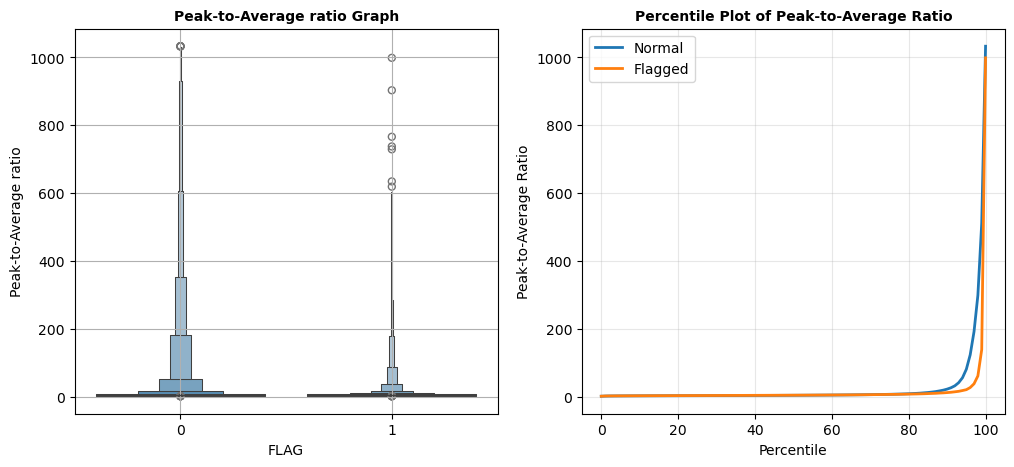

<Figure size 640x480 with 0 Axes>

In [119]:
# visulatization 1. Boxen Plot
fig,ax=plt.subplots(1,2,figsize=(12,5))
sns.boxenplot(data=consumer_feature,y='PAR',x='FLAG',
ax=ax[0])
ax[0].set_xlabel("FLAG")
ax[0].set_title("Peak-to-Average ratio Graph",fontweight='bold',fontsize=10)
ax[0].set_ylabel("Peak-to-Average ratio")
ax[0].grid()

# Percentile graph
normal=consumer_feature.loc[consumer_feature.FLAG==0,'PAR']
flagged=consumer_feature.loc[consumer_feature.FLAG==1,'PAR']
percentiles = np.arange(0,101)
norm=normal.dropna()
flag=flagged.dropna()
normal_pct= np.percentile(norm,percentiles)
flagged_pct= np.percentile(flag,percentiles)
plt.plot(percentiles,normal_pct,label='Normal',linewidth=2)
plt.plot(percentiles,flagged_pct,label='Flagged',linewidth=2)
plt.xlabel('Percentile')
plt.ylabel('Peak-to-Average Ratio')
plt.title("Percentile Plot of Peak-to-Average Ratio",fontweight='bold',fontsize=10)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


fig.suptitle("Boxen plot and ECDF of PAR",fontsize=15,fontweight='bold')
plt.show()
plt.tight_layout()

##### Observation and key findings
##### 1. Boxen plot->most consumer have low PAR,indicate stable usage and contain extreme outliers
##### 2. Percentile plot-> upto 90th percentile both behaves almost identical and curve dicerge only in the 5-10% of consumers.
##### 3. Feature importance for ML is moderate beacause it detects the sudden spikes but overlapping nature of graph limits it usefulness


### Feature 5:  Missing Reading Ratio 
#### To check the whether the reading is missed by any technical fault or a fraudulent behaviour.

In [120]:
# missing ratio = missing days/total days
consumer_feature['missing_ratio']=(consumer_feature['missing_days']/Total_days)
consumer_feature[['missing_ratio','CONS_NO','FLAG']].head(2)

,missing_ratio,CONS_NO,FLAG
0,0.003868,0387DD8A07E07FDA6271170F86AD9151,1
1,0.181818,01D6177B5D4FFE0CABA9EF17DAFC2B84,1


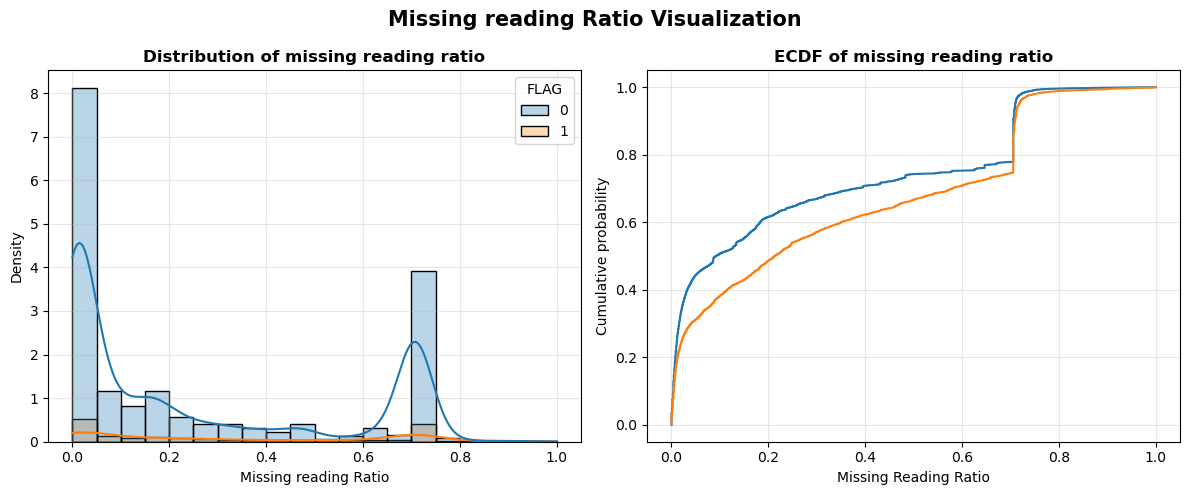

In [121]:
# Visualtization 1 : Histogrram with KDE plot
fig,ax=plt.subplots(1,2,figsize=(12,5))
sns.histplot(
    data=consumer_feature,x='missing_ratio',hue="FLAG",kde=True,
    bins=20,ax=ax[0],stat='density',alpha=0.3
)
ax[0].set_xlabel("Missing reading Ratio")
ax[0].set_ylabel("Density")
ax[0].set_title("Distribution of missing reading ratio",fontsize=12,fontweight='bold')
ax[0].grid(alpha=0.3)

# Visualtization 2 : Bar graph meand comaprison
normal=consumer_feature.loc[consumer_feature.FLAG==0,'missing_ratio']
flagged=consumer_feature.loc[consumer_feature.FLAG==1,'missing_ratio']
ecdf_flagged=ECDF(flagged)
ecdf_normal=ECDF(normal)
ax[1].plot(ecdf_normal.x,ecdf_normal.y,label="Normal")
ax[1].plot(ecdf_flagged.x,ecdf_flagged.y,label="Flagged")
ax[1].set_xlabel("Missing Reading Ratio")
ax[1].set_ylabel("Cumulative probability")
ax[1].set_title("ECDF of missing reading ratio",fontsize=12,fontweight='bold')
ax[1].grid(alpha=0.3)
fig.suptitle("Missing reading Ratio Visualization",fontsize=15,fontweight='bold')

plt.tight_layout()
plt.show()

##### Observations and key findings
##### 1. very low missing reading ratio,normal consumer much wider spread and noticable peak at 0.7 shows a consumer consistently high missing reading.
##### 2. flagged consumers are highly concentrated near 0.
##### 3. NOrmal ECDF rise faster in lower range indicate larger proportion of consumers with low MMR
##### 4. ML impact : Low to moderate 
##### 5. positive-> measure data wuality and meter reliability. Negative -> overlapping and weak standalone predictive capability.

## Spike Detection Featues

### Feature 6 : Spike Count
#### To check the observations that are not fit the standard pattern and detect the acitivity intensity and anomaly of the dataset 

In [122]:
daily_consumption = df1[date_col].head()

In [123]:
threshold=(
    consumer_feature['mean_cons']+3*consumer_feature['std_cons']
)
threshold.head()

0     10.252337
1     25.930304
2     39.182149
3     27.636882
4    260.884472
dtype: float64

In [124]:
consumer_feature['spike_count']=(
    daily_consumption.gt(threshold,axis=0).sum(axis=1)
)
consumer_feature[['CONS_NO','spike_count']].head()
consumer_feature['spike_count'].describe()

count    42372.000000
mean         0.002832
std          0.316174
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         47.000000
Name: spike_count, dtype: float64

In [125]:
top=consumer_feature.nlargest(10,'spike_count')[['CONS_NO','FLAG','spike_count']]

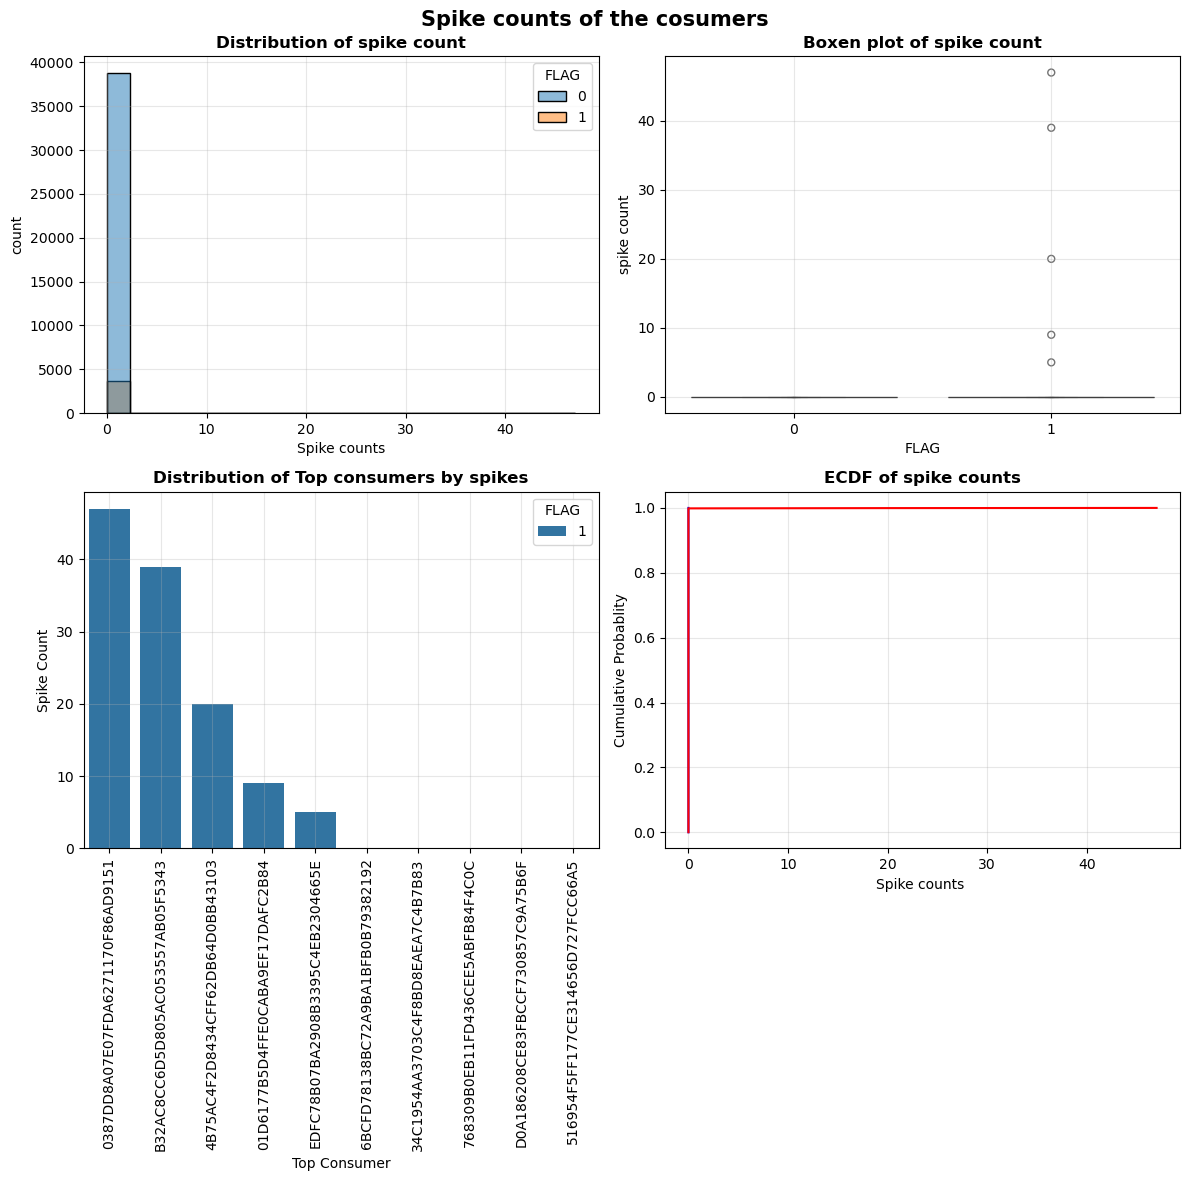

In [126]:
fig,ax=plt.subplots(2,2,figsize=(12,12))
# Visualization 1: Histogram 
sns.histplot(
    data=consumer_feature,x='spike_count',hue='FLAG',
    bins=20,multiple='layer',ax=ax[0,0]
)
ax[0,0].set_xlabel('Spike counts')
ax[0,0].set_ylabel('count')
ax[0,0].set_title('Distribution of spike count',fontsize=12,fontweight='bold')
ax[0,0].grid(alpha=0.3)
# Visualization 2: Boxenplot
sns.boxenplot(
    data=consumer_feature,x='FLAG',y='spike_count',
    ax=ax[0,1]
)
ax[0,1].set_xlabel('FLAG')
ax[0,1].set_ylabel('spike count')
ax[0,1].set_title('Boxen plot of spike count',fontsize=12,fontweight='bold')
ax[0,1].grid(alpha=0.3)
# Visulization 3: Top Consumers
sns.barplot(
    data=top,x='CONS_NO',y='spike_count',hue='FLAG',ax=ax[1,0])
ax[1,0].tick_params(axis='x',rotation=90)
plt.tight_layout()
ax[1,0].set_xlabel('Top Consumer')
ax[1,0].set_ylabel('Spike Count')
ax[1,0].set_title('Distribution of Top consumers by spikes',fontsize=12,fontweight='bold')
ax[1,0].grid(alpha=0.3)

# Visulization 4: ECDF of spike count
normal=consumer_feature.loc[
    consumer_feature.FLAG==0,'spike_count'
]
flagged=consumer_feature.loc[
    consumer_feature.FLAG==1,'spike_count'
]
ecdf_normal=ECDF(normal)
ecdf_flagged=ECDF(flagged)
ax[1,1].plot(ecdf_normal.x,ecdf_normal.y,label='Normal',color='blue')
ax[1,1].plot(ecdf_flagged.x,ecdf_flagged.y,label='Flagged',color='red')
ax[1,1].set_xlabel('Spike counts ')
ax[1,1].set_ylabel('Cumulative Probablity')
ax[1,1].set_title('ECDF of spike counts',fontsize=12,fontweight='bold')
ax[1,1].grid(alpha=0.3)

fig.suptitle("Spike counts of the cosumers",fontsize=15,fontweight='bold')
plt.tight_layout()

In [127]:
# statistical test 
from scipy.stats import mannwhitneyu 
stat,p= mannwhitneyu(normal,flagged)
print(stat)
print(p)

69956385.0
2.4447224119537026e-13


In [ ]:
# Validation 
_id=consumer_feature['CONS_NO'].sample(5,random_state=42)
for cid in sample_id :
    values=df1.loc[df1['CONS_NO'] == cid,date_col].iloc[0]
    threshold= consumer_feature.loc[
        consumer_feature.CONS_NO==cid,'mean_cons'].iloc[0]+3*consumer_feature.loc[consumer_feature.CONS_NO==cid,'std_cons'].iloc[0]
print(f'\nCosumer:{cid}') 
print(f'Threshold:{threshold:.2f}')      
print(f'calculated spike count {(values>threshold).sum()}')


Cosumer:D337C05D2897E43B60968F708203C995
Threshold:2.04
calculated spike count 6


##### Observation and key findinds
##### 1. Most cosumers have 0 or low few spikes and flagged consumer has higher spike count region.
##### 2. median spike for both is close to 0 and flagged consumercontain extreme outlier 
##### 3. some consumers have high spike counts and require further investigation
##### 4. ECDF rises almost vertically at 0 sppike and show vast majority of consumers 

### Feature 7: Spike Ratio
#### To make spike behaviour comparable across consumers, we normalize spike count by valid reading.

In [129]:
# spike ratio = spike count/valid days
# valid days = total days - missing days
consumer_feature['spike_ratio']=(
    consumer_feature['spike_count']/
    consumer_feature['valid_days']
)
consumer_feature['spike_ratio'].describe()

count    42367.000000
mean         0.000003
std          0.000331
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.045631
Name: spike_ratio, dtype: float64

Text(0.5, 0.98, 'Spike ratio visualization')

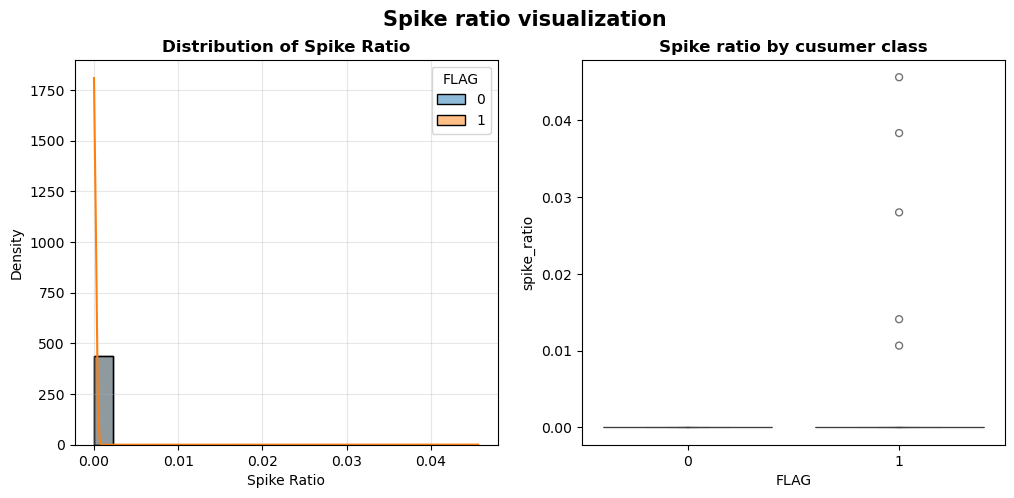

In [130]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
sns.histplot(
    data=consumer_feature,x='spike_ratio',hue='FLAG',bins=20,
    kde=True,stat='density',common_norm=False,ax=ax[0]
)
ax[0].set_title("Distribution of Spike Ratio",fontsize=12,fontweight='bold')
ax[0].set_xlabel("Spike Ratio")
ax[0].set_ylabel("Density")
ax[0].grid(alpha=.3)

sns.boxenplot(
    data=consumer_feature,x='FLAG',y='spike_ratio',ax=ax[1]
)
ax[1].set_title('Spike ratio by cusumer class',fontsize=12,fontweight='bold')
fig.suptitle("Spike ratio visualization",fontsize=15,fontweight='bold')

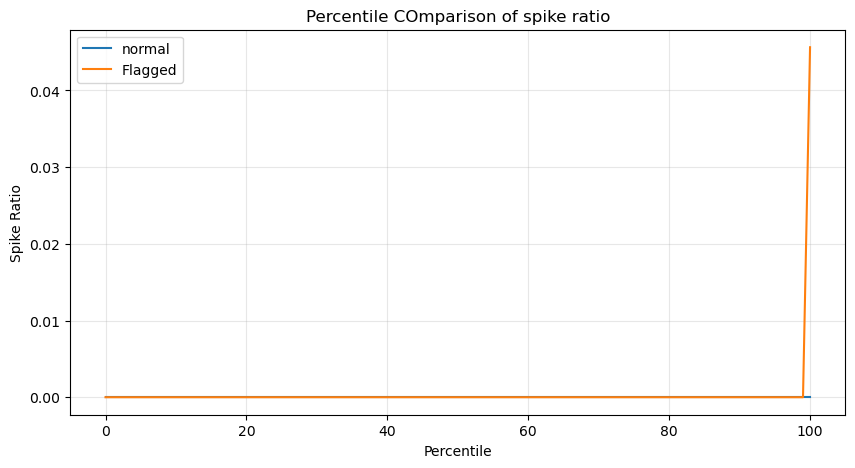

In [131]:
normal=consumer_feature.loc[consumer_feature.FLAG==0,'spike_ratio'].dropna()
flagged=consumer_feature.loc[consumer_feature.FLAG==1,'spike_ratio'].dropna()
normal_pct=np.percentile(normal,percentiles)
flagged_pct=np.percentile(flagged,percentiles)
plt.figure(figsize=(10,5))
plt.plot(percentiles,normal_pct,label='normal')
plt.plot(percentiles,flagged_pct,label='Flagged')
plt.xlabel("Percentile")
plt.ylabel("Spike Ratio")
plt.title("Percentile COmparison of spike ratio")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [132]:
# Statistical Test 
stat,p=mannwhitneyu(normal,flagged,alternative='two-sided')
print(f'Statistic : {stat:.2f}')
print(f'P-value : {p:.5f}')

Statistic : 69894642.50
P-value : 0.00000


#### Observation and key findings 
##### 1. majority of consumer exhibit stable elctricity usage
##### 2. high spike ratio is rarely present but predominantly found in flagged class
##### 3. spike ratio captures sudden abnormal events 
##### 4. it is highly effective for detecting rare,high risk electricity theft cases.

### Feature 8 : Longest Zero Consumption Streak
#### The longest consecutive zero-consumption period is extracted as a behavioural features.

In [133]:
def longest_zero_streak(values):
    max_streak=0
    current_streak=0
    for value in values :
        if value==0:
            current_streak +=1
            max_streak = max(max_streak,current_streak)
        else :
            current_streak=0
    return max_streak
consumer_feature['longest_zero_streak']=(df1[date_col].apply(
    longest_zero_streak,axis=1
))

In [134]:
consumer_feature[['zero_days','longest_zero_streak','FLAG']].head()

,zero_days,longest_zero_streak,FLAG
0,862,374,1
1,50,50,1
2,34,12,1
3,797,372,1
4,38,35,1


In [135]:
consumer_feature.nlargest(10,'longest_zero_streak')[
    ['CONS_NO','FLAG','zero_days','longest_zero_streak']]

,CONS_NO,FLAG,zero_days,longest_zero_streak
20,720FAD7A2EA8095703804E9C897F159E,1,1033,758
300,DE9959333D3966C6B13EA1CC1831125E,1,962,758
326,2CF1C6EE6E3A009A13BAE2183C55B2EB,1,1033,758
554,078BEE7B81782AD1408B4180DEE18A9D,0,1030,758
562,AD1356A6814BDB4DF95B24C7D22E330E,0,1029,758
597,1B29E40410AA0E6B362EA329F0EA5776,0,1033,758
627,7068BE9053BBA4F8A5F6941ABB0B9F64,0,1028,758
629,4D1D03BA207B948328746ECDFBC4CF12,0,1033,758
642,68F868D79F7D41D3123B20452D05221A,0,1031,758
676,0F7DF32E33E04E28CC70DE7550A65142,0,1029,758


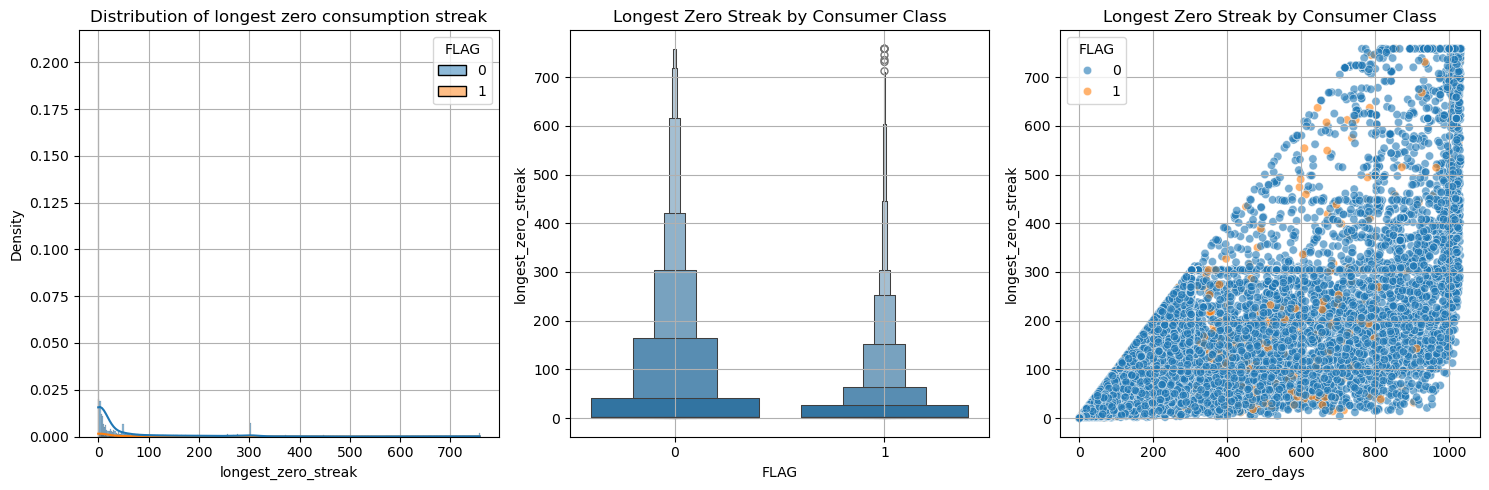

In [136]:
# Visualization 1 : histogram of longest zero streak 
fig,ax=plt.subplots(1,3,figsize=(15,5))
sns.histplot(
    data=consumer_feature,x='longest_zero_streak',hue='FLAG',kde=True,
    stat='density',ax=ax[0]
)
ax[0].set_title('Distribution of longest zero consumption streak')
# visualization 2 : Boxen plot for longest zero day streka

sns.boxenplot(
    data=consumer_feature,x='FLAG',y='longest_zero_streak',ax=ax[1]
)
ax[1].set_title("Longest Zero Streak by Consumer Class")
# visualization 3 : scatter plot for longest zero day streak vs zero days
sns.scatterplot(
    data=consumer_feature,x='zero_days',y='longest_zero_streak',hue='FLAG',
    alpha=.6,ax=ax[2]
)
ax[2].set_title("Longest Zero Streak by Consumer Class")
ax[0].grid()
ax[2].grid()
ax[1].grid()
plt.tight_layout()
plt.show()

### Feature 9 – Longest Missing Reading Streak
#### A long uninterrupted sequence of missing meter readings may indicate communication failures, meter malfunction, data transmission issues or possible meter tampering.

In [137]:
def longest_missing_streak(values):

    max_streak = 0
    current_streak = 0

    for value in values:

        if pd.isna(value):
            current_streak += 1
            max_streak = max(max_streak, current_streak)

        else:
            current_streak = 0

    return max_streak

In [138]:
date_cols=[col for col in df1.columns if col not in ['CONS_NO','FLAG']]
consumer_feature["longest_missing_streak"] = (
    df1[date_cols].apply(longest_missing_streak, axis=1)
)

In [139]:
consumer_feature[['missing_days','longest_missing_streak']].head()

,missing_days,longest_missing_streak
0,4,2
1,188,158
2,320,28
3,17,6
4,679,676


In [140]:
consumer_feature['longest_missing_streak'].describe()

count    42372.000000
mean       244.583003
std        296.187026
min          1.000000
25%          4.000000
50%         84.000000
75%        535.250000
max       1034.000000
Name: longest_missing_streak, dtype: float64

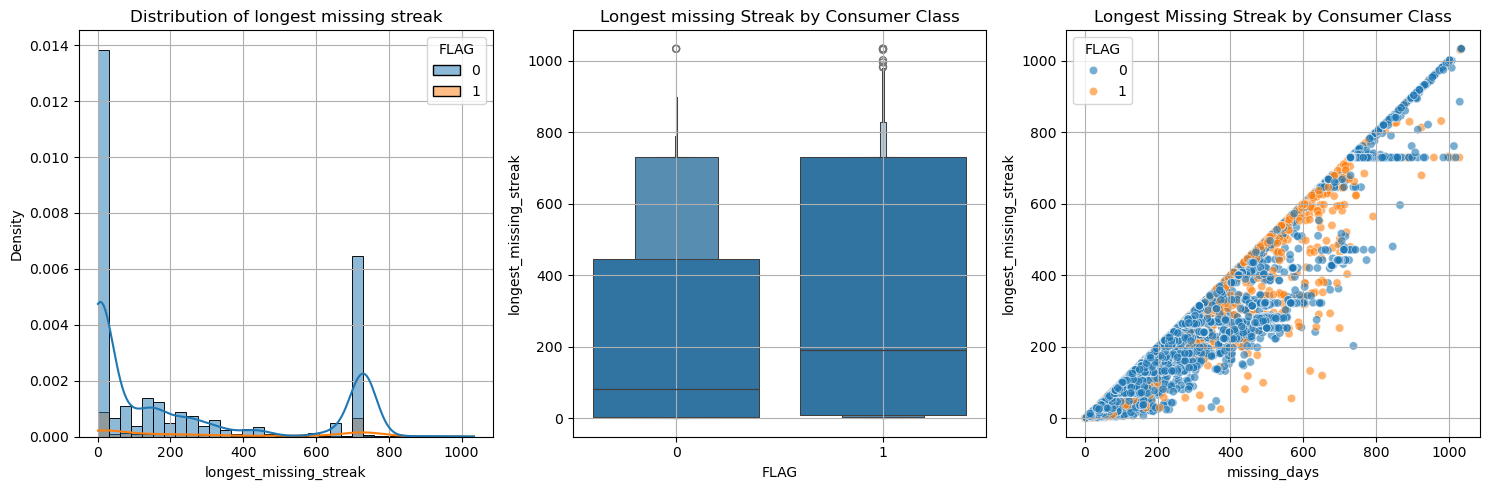

In [141]:
# Visualization 1 : histogram of longest missing streak 
fig,ax=plt.subplots(1,3,figsize=(15,5))
sns.histplot(
    data=consumer_feature,x='longest_missing_streak',hue='FLAG',kde=True,
    stat='density',ax=ax[0]
)
ax[0].set_title('Distribution of longest missing streak')
# visualization 2 : Boxen plot for longest zero day streka

sns.boxenplot(
    data=consumer_feature,x='FLAG',y='longest_missing_streak',ax=ax[1]
)
ax[1].set_title("Longest missing Streak by Consumer Class")
# visualization 3 : scatter plot for longest zero day streak vs zero days
sns.scatterplot(
    data=consumer_feature,x='missing_days',y='longest_missing_streak',hue='FLAG',
    alpha=.6,ax=ax[2]
)
ax[2].set_title("Longest Missing Streak by Consumer Class")
ax[0].grid()
ax[2].grid()
ax[1].grid()
plt.tight_layout()
plt.show()


In [142]:
# statistical test 
normal=consumer_feature.loc[consumer_feature.FLAG==0,'longest_missing_streak']
flagged=consumer_feature.loc[consumer_feature.FLAG==1,'longest_missing_streak']
stats,p=mannwhitneyu(normal,flagged,alternative='two-sided')
print('statistics:',stats)
print('P-value:',p)

statistics: 59397552.5
P-value: 1.9511903427735487e-52


##### Observation and key findings
##### 1. graph 1: One peak near 0 shoes many consumers have little or no consecutive missing reading and both appear in the high streak reagion
##### 2. graph 2: flagged consumer has higher median longest missing streak and they show greter variability
##### 3. graph 3: Strong positive relationship between total missing days and longest missing streak most points lie close to diagonal.
##### 4. ML impact : Improve the ability of tree-based modela to detect suspicious consumers.

## Phase 4 : Temporal Behaviour 

### Feature 10 : High Consumption Day Ratio ( HCDR )
#### consumes with a higher HDCR may exhibit irregular or highly variable consumption behaviour.

In [143]:
# HCDR = number of day above mean / Valid day
high_days=df1[date_cols].gt(consumer_feature['mean_cons'],axis=0)
consumer_feature['high_cons_days']=(
    high_days.sum(axis=1)
)

In [144]:
consumer_feature['high_cons_ratio']=(
    consumer_feature['high_cons_days']/consumer_feature['valid_days']
)
consumer_feature['high_cons_ratio'].describe()

count    42367.000000
mean         0.356380
std          0.149828
min          0.000000
25%          0.306769
50%          0.392929
75%          0.450658
max          0.973913
Name: high_cons_ratio, dtype: float64

In [145]:
consumer_feature.head()

,CONS_NO,FLAG,mean_cons,median_cons,std_cons,min_cons,max_cons,total_cons,zero_days,missing_days,...,zero_ratio,high_cons_ratio,PAR,cv,Stability,MMG,missing_ratio,spike_count,spike_ratio,longest_zero_streak
0,0387DD8A07E07FDA6271170F86AD9151,1,0.947796,0.000,3.101514,0.0,18.29,976.23,862,4,...,0.836893,0.105825,19.297399,1.592320,0.385755,0.947796,0.003868,47,0.045631,374
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,4.606312,0.955,7.107997,0.0,44.57,3896.94,50,188,...,0.059102,0.314421,9.675853,1.267856,0.440945,3.651312,0.181818,9,0.010638,50
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,8.312549,5.070,10.289867,0.0,79.71,5935.16,34,320,...,0.047619,0.382353,9.589116,1.104946,0.475072,3.242549,0.309478,20,0.028011,12
3,B32AC8CC6D5D805AC053557AB05F5343,1,3.638446,0.000,7.999479,0.0,40.98,3700.30,797,17,...,0.783677,0.216323,11.263049,1.724603,0.367026,3.638446,0.016441,39,0.038348,372
4,EDFC78B07BA2908B3395C4EB2304665E,1,67.649718,52.440,64.411585,0.0,399.40,24015.65,38,679,...,0.107042,0.343662,5.903942,0.938264,0.515925,15.209718,0.656673,5,0.014085,35


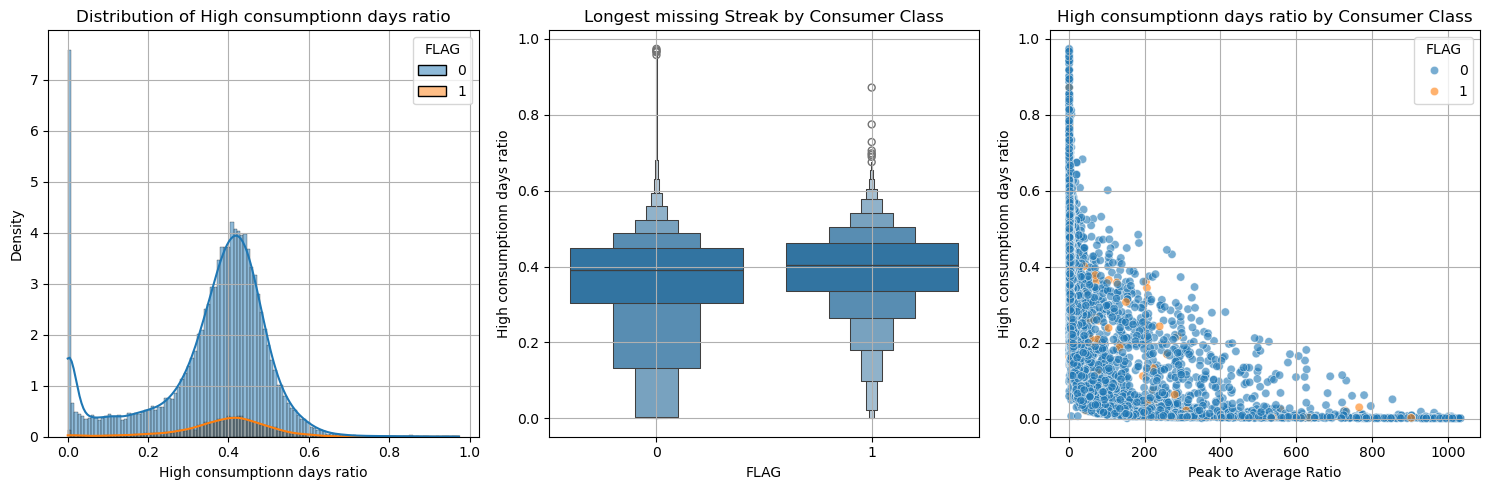

In [146]:
# Visualization 1 : histogram of High consumption days ratio
fig,ax=plt.subplots(1,3,figsize=(15,5))
sns.histplot(
    data=consumer_feature,x='high_cons_ratio',hue='FLAG',kde=True,
    stat='density',ax=ax[0]
)
ax[0].set_title('Distribution of High consumptionn days ratio')
ax[0].set_xlabel("High consumptionn days ratio")
ax[0].set_ylabel("Density")

# visualization 2 : Boxen plot for High consumptionn days ratio

sns.boxenplot(
    data=consumer_feature,x='FLAG',y='high_cons_ratio',ax=ax[1]
)
ax[1].set_title("Longest missing Streak by Consumer Class")
ax[1].set_xlabel("FLAG")
ax[1].set_ylabel("High consumptionn days ratio")
# visualization 3 : scatter plot for High consumptionn days ratios
sns.scatterplot(
    data=consumer_feature,x='PAR',y='high_cons_ratio',hue='FLAG',
    alpha=.6,ax=ax[2]
)
ax[2].set_title("High consumptionn days ratio by Consumer Class")
ax[2].set_xlabel("Peak to Average Ratio")
ax[2].set_ylabel("High consumptionn days ratio")
ax[0].grid()

ax[2].grid()
ax[1].grid()
plt.tight_layout()
plt.show()


#### Observation and key findings
##### 1. most consumers have an HCDR bwtween 0.35 and 0.45 that show balanced consumption around their personal average.
##### 2. both classes shows substantial oberlap so low classification power
##### 3. flagged consumers exhibit slightly greater variablity.
##### 4. Their is clear inverse relationship between HCDR and PAR 
##### 5. HCDR is a best treated as a supportinf behaviourl feature

### Feature 11 : Consumption Stability Score 
#### Large fluctuations in daily consumption may indicate abnormal behaviour or electricity theft.

In [147]:
# Stability = 1/(1+CV)
consumer_feature['Stability']=(
    1/(1+consumer_feature['cv'])
)

In [148]:
# Validation 
consumer_feature[['CONS_NO','FLAG','Stability']].head(5)


,CONS_NO,FLAG,Stability
0,0387DD8A07E07FDA6271170F86AD9151,1,0.385755
1,01D6177B5D4FFE0CABA9EF17DAFC2B84,1,0.440945
2,4B75AC4F2D8434CFF62DB64D0BB43103,1,0.475072
3,B32AC8CC6D5D805AC053557AB05F5343,1,0.367026
4,EDFC78B07BA2908B3395C4EB2304665E,1,0.515925


In [149]:
consumer_feature['Stability'].describe()

count    42367.000000
mean         0.685438
std          0.156220
min          0.030852
25%          0.597878
50%          0.692157
75%          0.769789
max          1.000000
Name: Stability, dtype: float64

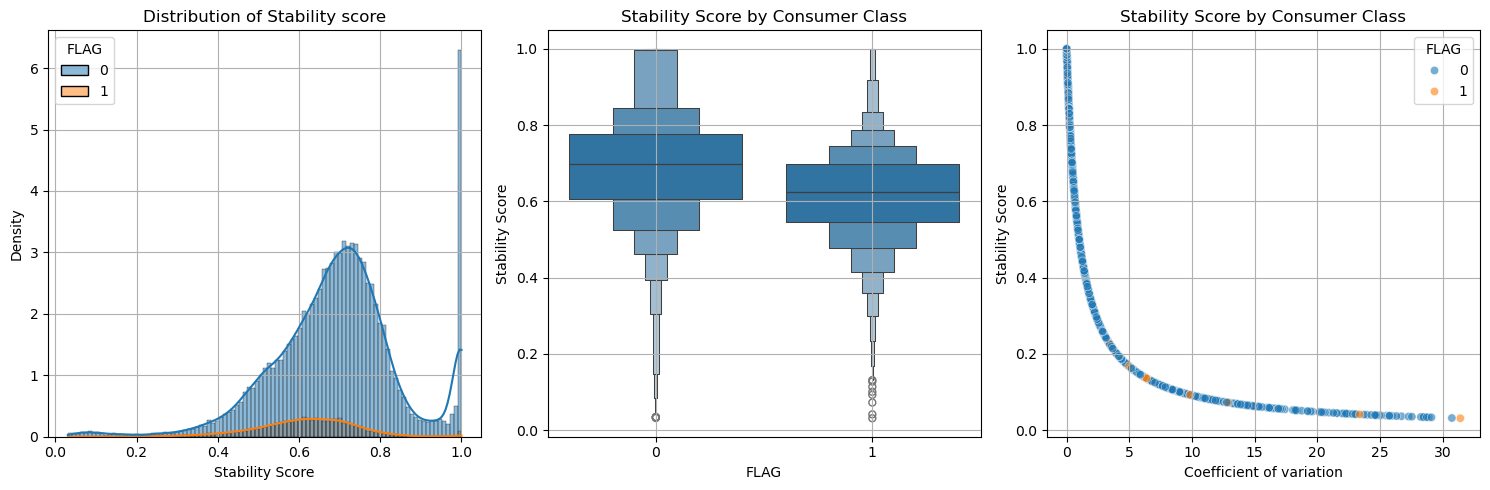

In [150]:
# Visualization 1 : histogram of Stability Score
fig,ax=plt.subplots(1,3,figsize=(15,5))
sns.histplot(
    data=consumer_feature,x='Stability',hue='FLAG',kde=True,
    stat='density',ax=ax[0]
)
ax[0].set_title('Distribution of Stability score')
ax[0].set_xlabel("Stability Score")
ax[0].set_ylabel("Density")

# visualization 2 : Boxen plot for Stability Score
sns.boxenplot(
    data=consumer_feature,x='FLAG',y='Stability',ax=ax[1]
)
ax[1].set_title("Stability Score by Consumer Class")
ax[1].set_xlabel("FLAG")
ax[1].set_ylabel("Stability Score")
# visualization 3 : scatter plot for Stability Score
sns.scatterplot(
    data=consumer_feature,x='cv',y='Stability',hue='FLAG',
    alpha=.6,ax=ax[2]
)
ax[2].set_title("Stability Score by Consumer Class")
ax[2].set_xlabel("Coefficient of variation")
ax[2].set_ylabel("Stability Score")
ax[0].grid()

ax[2].grid()
ax[1].grid()
plt.tight_layout()
plt.show()


In [151]:
normal=consumer_feature.loc[
    consumer_feature.FLAG==0,'Stability'
]
flagged=consumer_feature.loc[
    consumer_feature.FLAG==1,'Stability'
]
stats,p=mannwhitneyu(normal,flagged,alternative='two-sided')
print("Statistics : ", stats)
print('P-value : ',p)

Statistics :  nan
P-value :  nan


#### Observation and key findings
##### 1. Most consumerss have stabiltiy score between 0.6 and 0.8 
##### 2. flagged consumers tend to have slightly lower stability
##### 3. the box plot shows a downward shift in the median stabiltiy for flagged consumers moderate discriminativr power
##### 4. Strong inverse relationship between stability score and coefficient of variation 
##### 5. Stability Score is a behavioral feature that works best when combined with Peak-to-Average Ratio, Spike Ratio, Zero Consumption Ratio, High Consumption Day Ratio, and Missing Reading features

In [155]:
%store consumer_feature

Stored 'consumer_feature' (DataFrame)
